# Kenya Coffee Research - Statistical Analysis
## Predicting Coffee Yield Variation Using Climate Data (1990-2024)

**Author:** Doreen Molly Wanjiru
**Dataset:** 35 years (1990-2024)
**Date:** June 2026

---

## Analysis Workflow

This notebook follows the following steps:
1. **Descriptive Statistics** - Understanding the data
2. **Exploratory Visualizations** - Identifying patterns
3. **Regression Assumptions Testing** - Validating modeling approach
4. **Regression Modeling** - Identifying significant variables
5. **Advanced Visualizations** - Communicating findings

---

##Setup & Data Loading

In [2]:
import sys
!{sys.executable} -m pip install scipy

print("SciPy installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 14.0 MB/s  0:00:01m0:00:0100:01
SciPy installed successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

In [5]:
# setting up display and visualization settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("KENYA COFFEE RESEARCH - STATISTICAL ANALYSIS")
print("="*80)
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("="*80)

KENYA COFFEE RESEARCH - STATISTICAL ANALYSIS
Analysis Date: 2026-06-23 12:02


In [7]:
data_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/master_data_1990_2024.csv'
df = pd.read_csv(data_path)

print(f"\n Data loaded successfully!")
print(f"  Shape: {df.shape[0]} observations × {df.shape[1]} variables")
print(f"  Time period: {df['Year'].min()}-{df['Year'].max()}")
print(f"\nVariables in dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")


 Data loaded successfully!
  Shape: 35 observations × 10 variables
  Time period: 1990-2024

Variables in dataset:
  1. Year
  2. Area_Ha
  3. Production_Tonnes
  4. Yield_Kg_Ha
  5. Production_Value_1000USD
  6. Value_Unit
  7. Temperature
  8. Precipitation
  9. Humidity
  10. Solar_Radiation


In [8]:
print("\nFirst 10 rows:")
df.head(10)


First 10 rows:


,Year,Area_Ha,Production_Tonnes,Yield_Kg_Ha,Production_Value_1000USD,Value_Unit,Temperature,Precipitation,Humidity,Solar_Radiation
0,1990,153100.000,103900.000,678.600,425834,1000 USD,17.825,44.499,11.482,20.186
1,1991,155400.000,86400.000,556.000,354110,1000 USD,18.321,36.425,10.948,20.752
2,1992,153800.000,85300.000,554.600,349602,1000 USD,18.271,35.837,10.859,20.538
3,1993,158200.000,75100.000,474.700,307797,1000 USD,17.989,38.087,10.878,20.632
4,1994,158700.000,79900.000,503.500,327470,1000 USD,18.279,44.731,11.013,21.080
5,1995,160500.000,95400.000,594.400,390996,1000 USD,17.979,41.650,11.287,20.509
6,1996,177400.000,97976.000,552.300,401554,1000 USD,17.902,39.834,11.150,20.241
7,1997,176907.000,68642.000,388.000,281329,1000 USD,18.290,49.452,11.041,20.479
8,1998,178500.000,53715.000,300.900,220151,1000 USD,17.919,43.059,11.916,20.074
9,1999,170000.000,68100.000,400.600,279108,1000 USD,18.631,28.574,10.454,20.846


# Section 1: Descritpive Statistics

We will understand our data through:
1. **Summary statistics** (mean, median, SD, min, max)
2. **Distribution characteristics** (skewness, kurtosis)
3. **Variability measures** (coefficient of variation)
4. **Normality tests** (Shapiro-Wilk)
5. **Bivariate correlations** (relationships between variables)
6. **Temporal trends** (changes over time)

---
## 1.1: Defining Variable Groups

In [9]:
dependent_var = 'Yield_Kg_Ha'
independent_vars = ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']
all_vars = [dependent_var] + independent_vars

print("Variable Structure:")
print(f"  Dependent variable (Y):     {dependent_var}")
print(f"  Independent variables (X):  {', '.join(independent_vars)}")

Variable Structure:
  Dependent variable (Y):     Yield_Kg_Ha
  Independent variables (X):  Temperature, Precipitation, Humidity, Solar_Radiation


## 1.2 Summary Statistics
Let's start with basic descriptive statistics for all key variables.

In [11]:
summary = df[all_vars].describe()

print("="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary.round(2))

print("\n" + "="*80)
print("ADDITIONAL STATISTICS")
print("="*80)
print(f"{'Variable':<20} {'Median':>10} {'Range':>12} {'IQR':>10}")
print("-"*52)

for var in all_vars:
    median = df[var].median()
    range_val = df[var].max() - df[var].min()
    iqr = df[var].quantile(0.75) - df[var].quantile(0.25)
    print(f"{var:<20} {median:>10.2f} {range_val:>12.2f} {iqr:>10.2f}")

SUMMARY STATISTICS
       Yield_Kg_Ha  Temperature  Precipitation  Humidity  Solar_Radiation
count       35.000       35.000         35.000    35.000           35.000
mean       398.610       18.480         40.480    11.260           20.580
std        109.410        0.380         10.030     0.480            0.370
min        262.500       17.820         22.300    10.130           20.010
25%        311.150       18.280         35.990    10.990           20.280
50%        370.000       18.460         39.830    11.180           20.540
75%        462.200       18.760         44.620    11.500           20.840
max        678.600       19.200         66.520    12.580           21.320

ADDITIONAL STATISTICS
Variable                 Median        Range        IQR
----------------------------------------------------
Yield_Kg_Ha              370.00       416.10     151.05
Temperature               18.46         1.38       0.48
Precipitation             39.83        44.22       8.63
Humidity       

#### Intepretation:

Based on the data, we can see that our dependent variable(yield) ranges between 262.5 kg/ha and 678.6 kg/ha (a 2.6x difference). Yield variation indicates environmental factors strongly influence crop performance.The mean(398.61) is also slightly right-skewed since it is greater than the median(370.00). 

Precipitation is the independent variable that has the widest range: 22.3 - 66.5 mm (nearly a 3x difference). It will probably be the strongest predictor of yield due to its high variability. 

Temperature, humidity and solar radiation on the other hand have limited variations hence have limited standalone predictive power. 

## 1.3 Distribution Characteristics

**Skewness** to measure asymmetry:
- **0** = perfectly symmetric
- **-ve** = left-skewed
- **+ve** = right-skewed
- |skewness| < 0.5 is fairly symmetric

**Kurtosis** to measure tail heaviness:
- **0** = normal distribution
- **+ve** = heavy tails (more outliers)
- **-ve** = light tails (fewer outliers)


In [16]:
print("="*80)
print("DISTRIBUTION CHARACTERISTICS")
print("="*80)
print(f"{'Variable':<20} {'Mean':>10} {'Std Dev':>10} {'Skewness':>10} {'Kurtosis':>10}")
print("-"*65)

for var in all_vars:
    mean = df[var].mean()
    std = df[var].std()
    skew = stats.skew(df[var])
    kurt = stats.kurtosis(df[var])
    print(f"{var:<20} {mean:>10.2f} {std:>10.2f} {skew:>10.3f} {kurt:>10.3f}")

print("\nInterpretation Guide:")
print("  Skewness: |value| < 0.5 (symmetric), 0.5-1 (moderate), >1 (highly skewed)")
print("  Kurtosis: 0 (normal), >0 (heavy-tailed), <0 (light-tailed)")

DISTRIBUTION CHARACTERISTICS
Variable                   Mean    Std Dev   Skewness   Kurtosis
-----------------------------------------------------------------
Yield_Kg_Ha              398.61     109.41      0.791     -0.308
Temperature               18.48       0.38     -0.020     -0.812
Precipitation             40.48      10.03      0.704      0.442
Humidity                  11.26       0.48      0.477      0.946
Solar_Radiation           20.58       0.37      0.380     -0.669

Interpretation Guide:
  Skewness: |value| < 0.5 (symmetric), 0.5-1 (moderate), >1 (highly skewed)
  Kurtosis: 0 (normal), >0 (heavy-tailed), <0 (light-tailed)


Yield_Kg_Ha:
Distribution has a longer tail toward high yields(skewness = 0.791); most observations cluster at lower-to-average values with some high performers.
Fewer extreme values than normal distribution (Kurtosis = -0.308); yields are relatively concentrated around the mean without many outliers.
Variable may benefit from log transformation if used in linear regression to normalize distribution.

Precipitation:
Most observations (skewness = 0.704) are at lower-to-moderate precipitation levels with some notably high rainfall events.
Modest presence of extreme precipitation values(Kurtosis = 0.442); occasional heavy rainfall periods.
Asymmetric distribution. May consider square root or log transformation to normalize for certain models.

Humidity:
Nearly symmetric with values evenly distributed around the mean.
Heavy-tailed (kurtosis = 0.946); more extreme values than normal distribution despite narrow range.
Despite low variance, frequent extremes may indicate threshold effects worth investigating.

Temperature and Solar Radiation:
Both are symmetric, with values evenly distributed around the mean. They have more uniform distribution without many extremes. 






## 1.4 Coefficient of Variation (CV)

The CV measures relative variability (standard deviation as a percentage of the mean).

**Interpretation:**
- **CV < 15%** = Low variability (stable)
- **CV 15-30%** = Moderate variability
- **CV > 30%** = High variability (volatile)

This is useful for comparing variability across variables with different units.

In [17]:
print("="*80)
print("COEFFICIENT OF VARIATION (CV)")
print("="*80)
print(f"{'Variable':<20} {'Mean':>10} {'Std Dev':>10} {'CV %':>10} {'Interpretation':>15}")
print("-"*75)

for var in all_vars:
    mean = df[var].mean()
    std = df[var].std()
    cv = (std/mean) * 100

    if cv < 15:
        interp = "Low"
    elif cv < 30:
        interp = "Moderate"
    else:
        interp = "High"
    
    print(f"{var:<20} {mean:>10.2f} {std:>10.2f} {cv:>10.2f} {interp:>15}")


COEFFICIENT OF VARIATION (CV)
Variable                   Mean    Std Dev       CV %  Interpretation
---------------------------------------------------------------------------
Yield_Kg_Ha              398.61     109.41      27.45        Moderate
Temperature               18.48       0.38       2.04             Low
Precipitation             40.48      10.03      24.78        Moderate
Humidity                  11.26       0.48       4.30             Low
Solar_Radiation           20.58       0.37       1.78             Low


## 1.5 Normality Tests

We check if variables follow a normal distribution.

**Shapiro-Wilk Test:**
- **H₀** (null hypothesis): Data is normally distributed
- **H₁** (alternative): Data is NOT normally distributed
- **Decision rule**: If p-value > 0.05, we accept H₀ (data is normal)


In [18]:
print("="*80)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("="*80)
print(f"{'Variable':<20} {'W-statistic':>12} {'p-value':>10} {'Normal?':>12}")
print("-"*54)

for var in all_vars:
    stat, p_value = stats.shapiro(df[var])
    is_normal = "Yes ✓" if p_value > 0.05 else "No ✗"
    print(f"{var:<20} {stat:>12.4f} {p_value:>10.4f} {is_normal:>12}")

print("\nInterpretation:")
print("  If p > 0.05: Variable is normally distributed ✓")
print("  If p < 0.05: Variable deviates from normality ✗")

NORMALITY TESTS (Shapiro-Wilk)
Variable              W-statistic    p-value      Normal?
------------------------------------------------------
Yield_Kg_Ha                0.9165     0.0113         No ✗
Temperature                0.9684     0.4003        Yes ✓
Precipitation              0.9428     0.0682        Yes ✓
Humidity                   0.9670     0.3651        Yes ✓
Solar_Radiation            0.9589     0.2113        Yes ✓

Interpretation:
  If p > 0.05: Variable is normally distributed ✓
  If p < 0.05: Variable deviates from normality ✗


Shapiro-Wilk tests reveal that Yield_Kg_Ha significantly deviates from normality, which is consistent with its moderate right skewness (0.791). All predictor variables pass normality tests. 

This is not a problem for now since OLS regression assumes RESIDUALS are normal, not the variables themselves.

/var/folders/20/758jl_4d73v071lxtlj_nlfc0000gn/T/ipykernel_92619/3077405924.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = axes[2].boxplot(df['Yield_Kg_Ha'], vert=True, patch_artist=True)


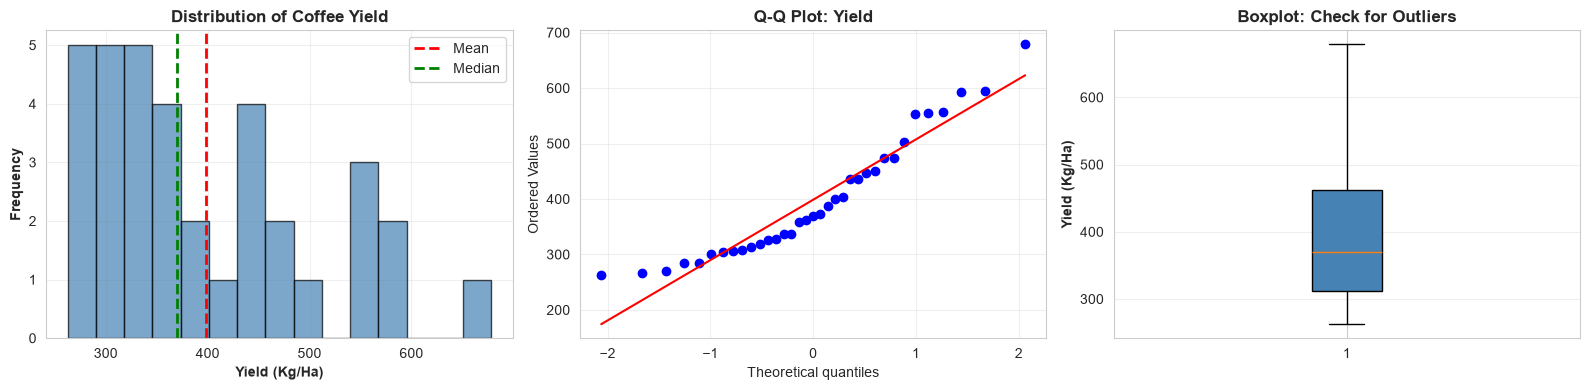

Yield Skewness: 0.791
  → Right-skewed (tail extends to the right)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['Yield_Kg_Ha'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['Yield_Kg_Ha'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df['Yield_Kg_Ha'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Yield (Kg/Ha)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Coffee Yield', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q Plot
stats.probplot(df['Yield_Kg_Ha'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Yield', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Boxplot
bp = axes[2].boxplot(df['Yield_Kg_Ha'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
axes[2].set_ylabel('Yield (Kg/Ha)', fontweight='bold')
axes[2].set_title('Boxplot: Check for Outliers', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/yield_normality_check.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Check skewness
skewness = stats.skew(df['Yield_Kg_Ha'])
print(f"Yield Skewness: {skewness:.3f}")
if skewness > 0:
    print("  → Right-skewed (tail extends to the right)")
elif skewness < 0:
    print("  → Left-skewed (tail extends to the left)")

The coffee yield shows mild right-skewness (0.791) and fails the Shapiro-Wilk normality test (p = 0.011).

We will use original yield (Kg/Ha) without transformation, a Level-Level Model.

This is because the skewness < 1.0 is acceptable for OLS with n=35, and coefficients will be directly interpretable for agricultural policy.


In [26]:
#Variables for modeling
df['Yield_Model'] = df['Yield_Kg_Ha']  # Primary: Original scale
df['Yield_Log'] = np.log(df['Yield_Kg_Ha'])  # Sensitivity check

print("✓ Primary model: Level-Level (Original Yield)")
print("✓ Sensitivity check: Log-Level (saved for Appendix)")

✓ Primary model: Level-Level (Original Yield)
✓ Sensitivity check: Log-Level (saved for Appendix)


## 1.6 Bivariate Correlations

How is each climate variable related to coffee yield?

**Pearson Correlation Coefficient (r):**
- Range: -1 to +1
- **r > 0**: Positive relationship (as X increases, Y increases)
- **r < 0**: Negative relationship (as X increases, Y decreases)
- **|r| < 0.3**: Weak correlation
- **|r| 0.3-0.7**: Moderate correlation
- **|r| > 0.7**: Strong correlation

**Significance levels:**
- *** p < 0.001 (highly significant)
- ** p < 0.01 (significant)
- * p < 0.05 (marginally significant)
- ns: not significant

In [29]:
print("="*80)
print("CORRELATIONS WITH YIELD")
print("="*80)
print(f"{'Variable':<20} {'Pearson r':>12} {'p-value':>10} {'Strength':>12} {'Significance':>15}")
print("-"*79)

for var in independent_vars:
    r, p_val = stats.pearsonr(df[dependent_var], df[var])
    
    # Determine strength
    if abs(r) < 0.3:
        strength = "Weak"
    elif abs(r) < 0.7:
        strength = "Moderate"
    else:
        strength = "Strong"
    
    # Determine significance
    if p_val < 0.001:
        sig = "*** (p<0.001)"
    elif p_val < 0.01:
        sig = "**  (p<0.01)"
    elif p_val < 0.05:
        sig = "*   (p<0.05)"
    else:
        sig = "ns  (p≥0.05)"
    
    print(f"{var:<20} {r:>12.3f} {p_val:>10.4f} {strength:>12} {sig:>15}")

print("\nInterpretation:")
print("  Positive r: Higher climate variable → Higher yield")
print("  Negative r: Higher climate variable → Lower yield")

CORRELATIONS WITH YIELD
Variable                Pearson r    p-value     Strength    Significance
-------------------------------------------------------------------------------
Temperature                -0.406     0.0155     Moderate    *   (p<0.05)
Precipitation               0.041     0.8154         Weak    ns  (p≥0.05)
Humidity                   -0.153     0.3805         Weak    ns  (p≥0.05)
Solar_Radiation             0.097     0.5783         Weak    ns  (p≥0.05)

Interpretation:
  Positive r: Higher climate variable → Higher yield
  Negative r: Higher climate variable → Lower yield


Temperature emerges as the only significant predictor (r = -0.406, p = 0.016), exhibiting a moderate negative relationship with yield. 

Surprisingly, precipitation shows virtually no linear correlation (r = 0.041, p = 0.815), contradicting initial expectations based on its high variability. This suggests precipitation may have non-linear effects, threshold relationships, or interact with other variables. 

Humidity and solar radiation show weak, non-significant correlations as anticipated given their limited variance.

## 1.7 Temporal Trends

Are variables increasing or decreasing over time (1990-2024)?

This helps us understand:
- Climate change patterns
- Long-term yield trends
- Whether we need to account for time in our models

In [32]:
print("="*80)
print("TEMPORAL TRENDS (Correlation with Year)")
print("="*80)
print(f"{'Variable':<20} {'Trend (r)':>12} {'p-value':>10} {'Direction':>15} {'Significant?':>15}")
print("-"*82)

for var in all_vars:
    r, p_val = stats.pearsonr(df['Year'], df[var])
    
    # Determine direction
    if r > 0.1:
        direction = "Increasing ↑"
    elif r < -0.1:
        direction = "Decreasing ↓"
    else:
        direction = "Stable →"
    
    # Significance
    sig = "Yes" if p_val < 0.05 else "No"
    
    print(f"{var:<20} {r:>12.3f} {p_val:>10.4f} {direction:>15} {sig:>15}")

print("\nInterpretation:")
print("  Positive r: Variable increasing over time")
print("  Negative r: Variable decreasing over time")
print("  |r| < 0.1: Variable relatively stable")

TEMPORAL TRENDS (Correlation with Year)
Variable                Trend (r)    p-value       Direction    Significant?
----------------------------------------------------------------------------------
Yield_Kg_Ha                -0.434     0.0092    Decreasing ↓             Yes
Temperature                 0.323     0.0581    Increasing ↑              No
Precipitation               0.435     0.0090    Increasing ↑             Yes
Humidity                    0.577     0.0003    Increasing ↑             Yes
Solar_Radiation            -0.081     0.6424        Stable →              No

Interpretation:
  Positive r: Variable increasing over time
  Negative r: Variable decreasing over time
  |r| < 0.1: Variable relatively stable


Both dependent and independent variables show significant time trends:
- Yield **declining** (r=-0.434, p=0.009)
- Precipitation **increasing** (r=0.435, p=0.009)  
- Humidity **increasing** (r=0.577, p<0.001)

There is a risk of **spurious correlation** whereby variables may correlate simply because both are trending over time, not due to causal relationship.

We will have to control for temporal trends in regression by adding **Year** as a control variable.